In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
#Load data set
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\Alvin IT Soln\New folder\customer_loan_approval.csv")
df.head()

,Income,Age,EmploymentStatus,CreditScore,LoanAmount,Education,ExistingDebts,LoanStatus
0,50000.0,25.0,Employed,720.0,150000.0,Graduate,10000.0,Approved
1,30000.0,22.0,Unemployed,580.0,200000.0,High School,50000.0,Rejected
2,80000.0,35.0,Employed,810.0,250000.0,Postgraduate,20000.0,Approved
3,45000.0,29.0,Self-Employed,690.0,180000.0,Graduate,15000.0,Approved
4,25000.0,21.0,Unemployed,540.0,120000.0,High School,30000.0,Rejected


In [3]:
#Display information and shape
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Income            9 non-null      float64
 1   Age               9 non-null      float64
 2   EmploymentStatus  9 non-null      str    
 3   CreditScore       9 non-null      float64
 4   LoanAmount        9 non-null      float64
 5   Education         10 non-null     str    
 6   ExistingDebts     9 non-null      float64
 7   LoanStatus        10 non-null     str    
dtypes: float64(5), str(3)
memory usage: 772.0 bytes


(10, 8)

In [4]:
#EDA process
df.describe()

,Income,Age,CreditScore,LoanAmount,ExistingDebts
count,9.000000,9.000000,9.000000,9.000000,9.000000
mean,50555.555556,29.222222,681.111111,196666.666667,25333.333333
std,17931.195659,6.220486,84.475506,54543.560573,12737.739203
min,25000.000000,21.000000,540.000000,120000.000000,10000.000000
25%,40000.000000,25.000000,640.000000,160000.000000,18000.000000
50%,50000.000000,29.000000,690.000000,190000.000000,20000.000000
75%,60000.000000,33.000000,720.000000,220000.000000,30000.000000
max,80000.000000,40.000000,810.000000,300000.000000,50000.000000


In [5]:
#Checking missing values
df.isnull().sum()

Income              1
Age                 1
EmploymentStatus    1
CreditScore         1
LoanAmount          1
Education           0
ExistingDebts       1
LoanStatus          0
dtype: int64

In [6]:
#Fillna
df["Income"] = df["Income"].fillna(df["Income"].mean())
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["CreditScore"] = df["CreditScore"].fillna(df["CreditScore"].mean())
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())
df["ExistingDebts"] = df["ExistingDebts"].fillna(df["ExistingDebts"].mean())
df["EmploymentStatus"] = df["EmploymentStatus"].fillna(df["EmploymentStatus"].mode()[0])
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])

In [7]:
#Checking missing values
df.isnull().sum()

Income              0
Age                 0
EmploymentStatus    0
CreditScore         0
LoanAmount          0
Education           0
ExistingDebts       0
LoanStatus          0
dtype: int64

In [8]:
# Create LabelEncoder object
le = LabelEncoder()
df["EmploymentStatus"] = le.fit_transform(df["EmploymentStatus"])
df["Education"] = le.fit_transform(df["Education"])
df["LoanStatus"] = le.fit_transform(df["LoanStatus"])
df.dtypes

Income              float64
Age                 float64
EmploymentStatus      int64
CreditScore         float64
LoanAmount          float64
Education             int64
ExistingDebts       float64
LoanStatus            int64
dtype: object

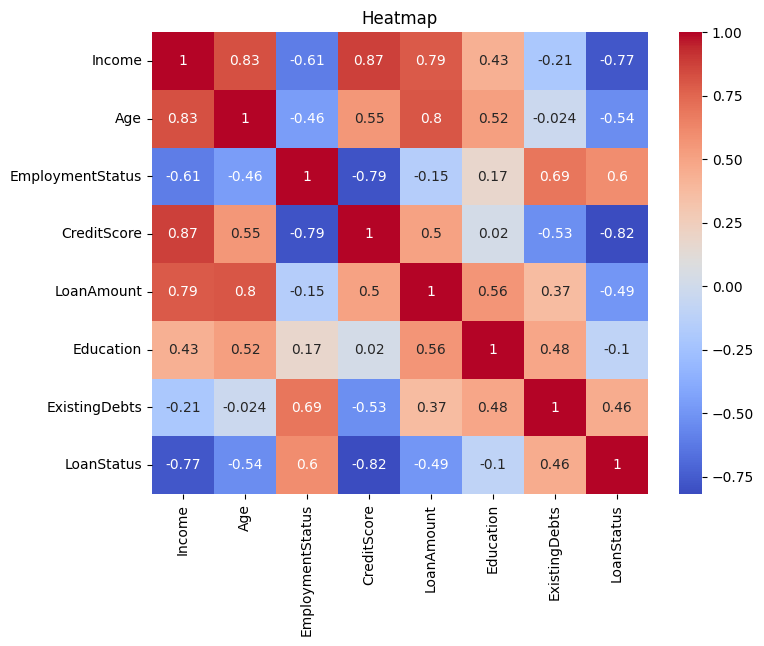

In [9]:
#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Heatmap")
plt.show()

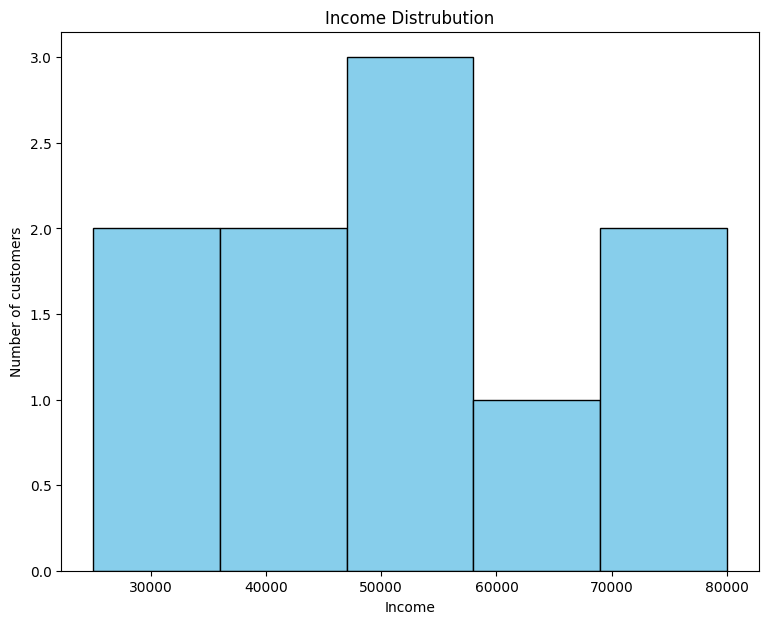

In [10]:
#Histogram 
plt.figure(figsize=(9,7))
plt.hist(df["Income"],bins=5,color="skyblue",edgecolor="black")
plt.title("Income Distrubution")
plt.xlabel("Income")
plt.ylabel("Number of customers")
plt.show()

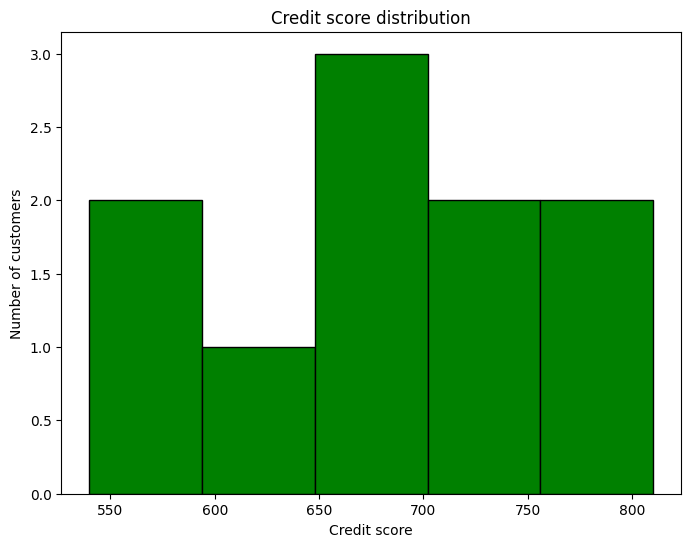

In [11]:
#Credit score distribution
plt.figure(figsize=(8,6))
plt.hist(df["CreditScore"],bins=5,color="green",edgecolor="black")
plt.title("Credit score distribution")
plt.xlabel("Credit score")
plt.ylabel("Number of customers")
plt.show()

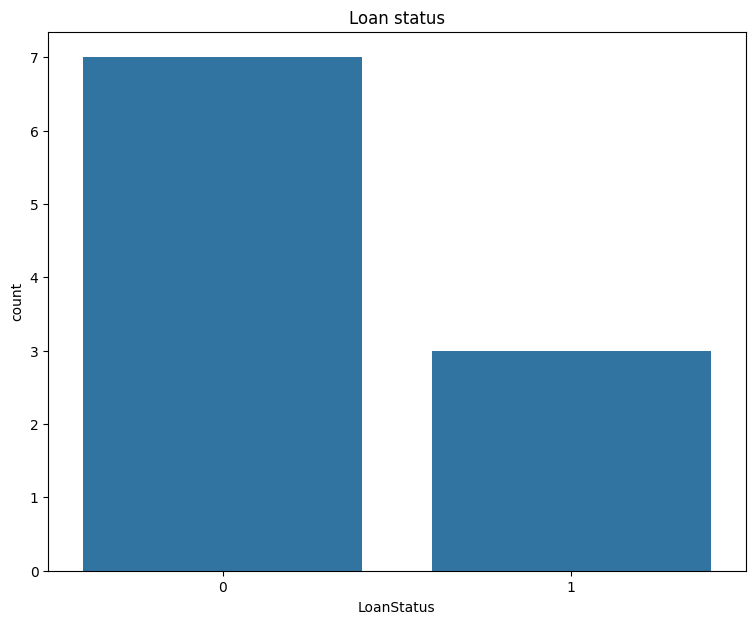

In [12]:
#Count plot
plt.figure(figsize=(9,7))
sns.countplot(x="LoanStatus",data=df)
plt.title("Loan status")
plt.show()

In [13]:
#Independent variables
x = df.drop("LoanStatus",axis=1)
#Dependent variables
y = df["LoanStatus"]
x.head()
y.head()

0    0
1    1
2    0
3    0
4    1
Name: LoanStatus, dtype: int64

In [14]:
#Train_Test_Split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)
print("Traning data:",x_train.shape)
print("Testing data:",x_test.shape)

Traning data: (8, 7)
Testing data: (2, 7)


In [15]:
#Random forest model
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
#Predict data
y_pred = model.predict(x_test)
print(y_pred)

[0 1]


In [17]:
#Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [18]:
#Confusion matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[1 0]
 [0 1]]


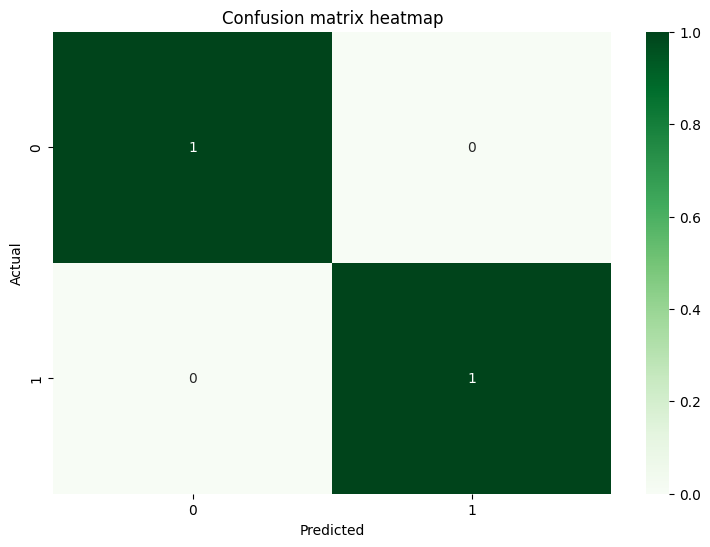

In [19]:
#Confusion matrix heatmap
plt.figure(figsize=(9,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")
plt.title("Confusion matrix heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [20]:
#Model accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [21]:
#Predict new customer 
new_customer = [[60000,30,0,750,200000,0,15000]]
prediction = model.predict(new_customer)
if prediction[0] ==1:
    print("Loan Approved")
else :
    print("Loan Rejected")

Loan Rejected


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
